In [1]:
import pandas as pd 
df=pd.read_csv("customer_shopping_behavior.csv")

In [2]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [4]:
df.describe(include="all")

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [5]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [6]:
df["Review Rating"]=df.groupby("Category")["Review Rating"].transform(lambda x: x.fillna(x.median()))

In [7]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [8]:
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(" ","_") 
df=df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [9]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [10]:
labels=["Young Adult","Adult","Middle-aged","Senior"]
df["age_group"]=pd.qcut(df['age'],q=4,labels=labels)

In [11]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [12]:
frequency_mapping={
    "Fortnightly":14,
    "Weekly":7,
    "Monthly":30,
    "Quarterly":90,
    "Bi-Weekly":14,
    "Annually":365,
    "Every 3 Months":90
}
df["purchase_frequency_days"]=df['frequency_of_purchases'].map(frequency_mapping)

In [13]:
df[["purchase_frequency_days","frequency_of_purchases"]].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [14]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [15]:
(df["discount_applied"]==df["promo_code_used"]).all()

np.True_

In [16]:
df=df.drop("promo_code_used",axis=1)

In [17]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

# Exploratory Data Analysis (EDA)

## Objective
Analyze customer demographics, purchasing behavior, and shopping patterns to derive meaningful business insights.

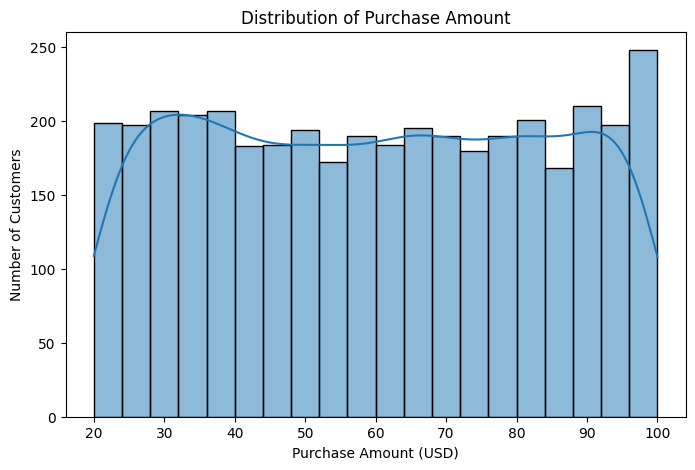

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df["purchase_amount"], bins=20, kde=True)

plt.title("Distribution of Purchase Amount")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Number of Customers")

plt.show()

### Business Insights

- Purchase amounts are fairly evenly distributed across the dataset.
- Most purchases fall between 20 and 100 USD.
- No significant skewness or extreme outliers are observed.

## Revenue by Product Category

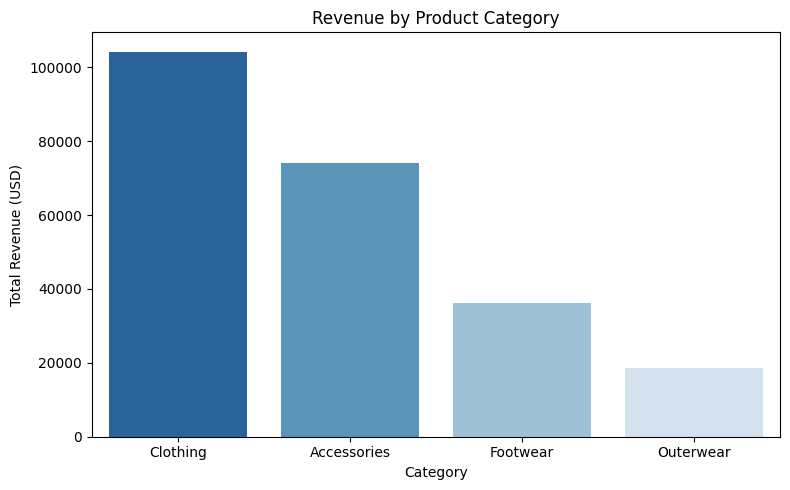

In [19]:
category_sales = (
    df.groupby("category")["purchase_amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    hue=category_sales.index,
    palette="Blues_r",
    legend=False
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue (USD)")

plt.tight_layout()
plt.show()

### Business Insights

- Clothing contributes the highest total revenue.
- Outerwear contributes the lowest revenue.
- The top-performing categories should receive more inventory and marketing focus.

## Revenue by Age Group

C:\Users\dk523\AppData\Local\Temp\ipykernel_14732\4033316959.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_group")["purchase_amount"]


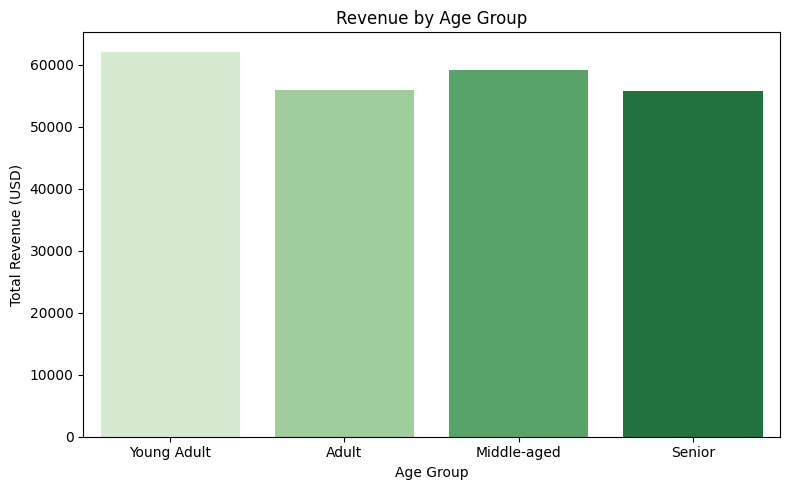

In [20]:
age_sales = (
    df.groupby("age_group")["purchase_amount"]
      .sum()
      .reindex(["Young Adult", "Adult", "Middle-aged", "Senior"])
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=age_sales.index,
    y=age_sales.values,
    hue=age_sales.index,
    palette="Greens",
    legend=False
)

plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Revenue (USD)")

plt.tight_layout()
plt.show()

### Business Insights

- Compare revenue contribution across different age groups.
- Identify the customer segment generating the highest sales.
- Use these insights to design targeted marketing campaigns for high-value age groups.

## Revenue by Gender

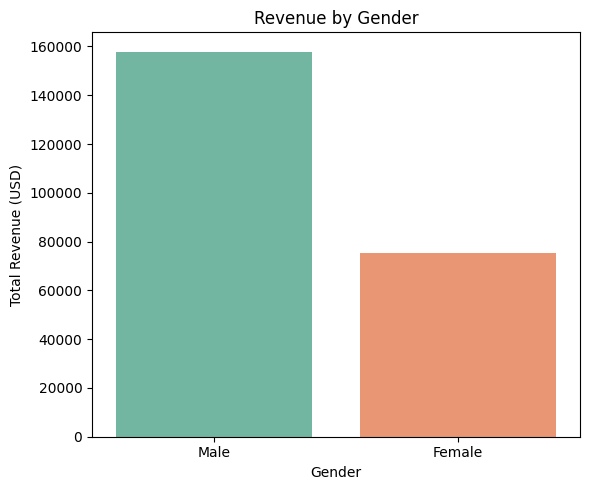

In [21]:
gender_sales = (
    df.groupby("gender")["purchase_amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(6,5))

sns.barplot(
    x=gender_sales.index,
    y=gender_sales.values,
    hue=gender_sales.index,
    palette="Set2",
    legend=False
)

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue (USD)")

plt.tight_layout()
plt.show()

### Business Insights

- Compare revenue contribution between male and female customers.
- Identify the gender segment generating higher sales.
- Use these insights to create gender-specific marketing campaigns.

## Revenue by Subscription Status

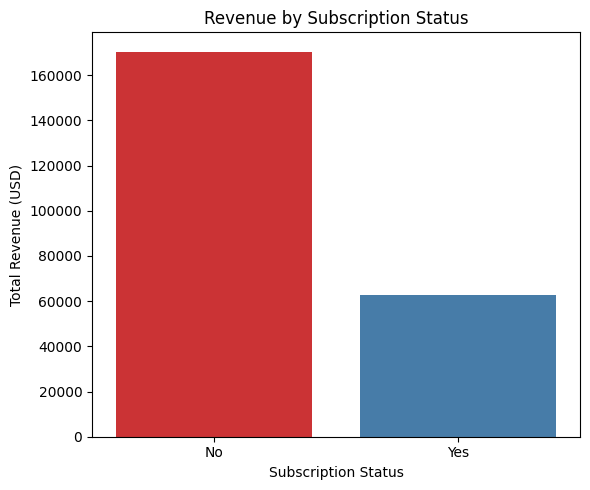

In [22]:
subscription_sales = (
    df.groupby("subscription_status")["purchase_amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(6,5))

sns.barplot(
    x=subscription_sales.index,
    y=subscription_sales.values,
    hue=subscription_sales.index,
    palette="Set1",
    legend=False
)

plt.title("Revenue by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Total Revenue (USD)")

plt.tight_layout()
plt.show()

### Business Insights

- Compare revenue generated by subscribed and non-subscribed customers.
- Identify whether subscriptions influence customer spending.
- Use these findings to improve subscription marketing strategies.

## Customer Review Rating Distribution

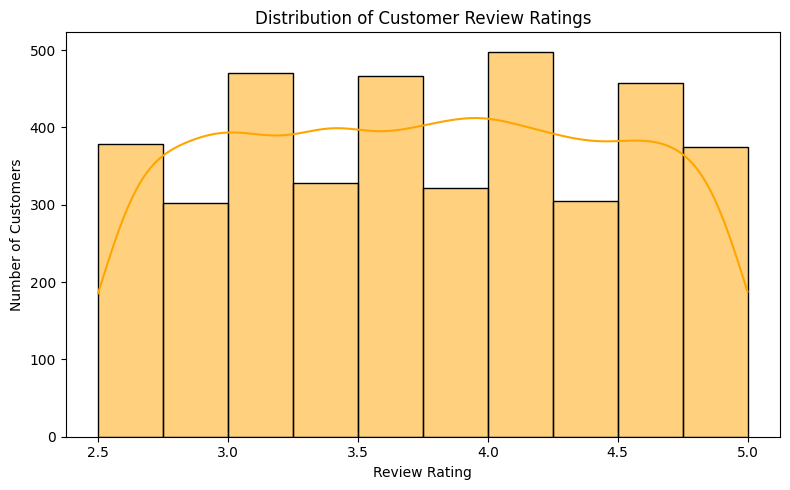

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["review_rating"],
    bins=10,
    kde=True,
    color="orange"
)

plt.title("Distribution of Customer Review Ratings")
plt.xlabel("Review Rating")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Business Insights

- Most customer ratings are concentrated around the average.
- Very low ratings are comparatively less frequent.
- Customer satisfaction appears relatively stable across purchases.

## Shipping Type Distribution

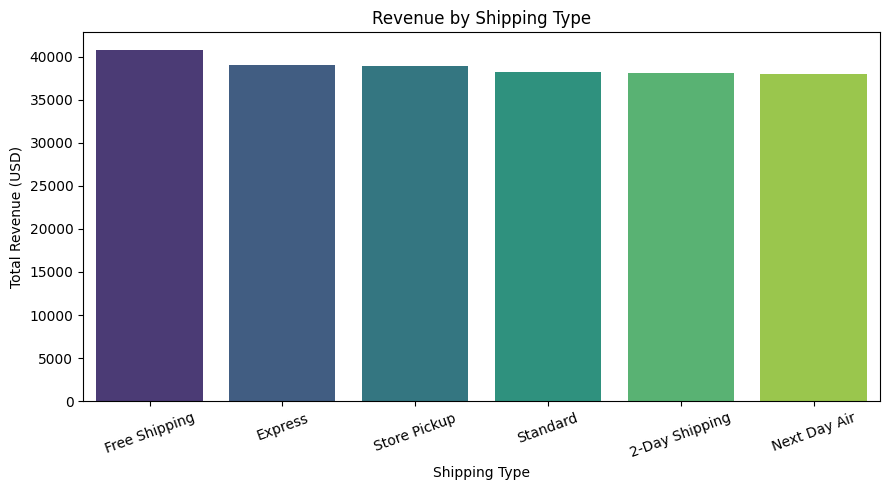

In [24]:
shipping_sales = (
    df.groupby("shipping_type")["purchase_amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=shipping_sales.index,
    y=shipping_sales.values,
    hue=shipping_sales.index,
    palette="viridis",
    legend=False
)

plt.title("Revenue by Shipping Type")
plt.xlabel("Shipping Type")
plt.ylabel("Total Revenue (USD)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Business Insights

- Compare revenue generated across different shipping methods.
- Identify the shipping option preferred by high-spending customers.
- Optimize logistics and promotional offers based on customer shipping preferences.

## Correlation Heatmap

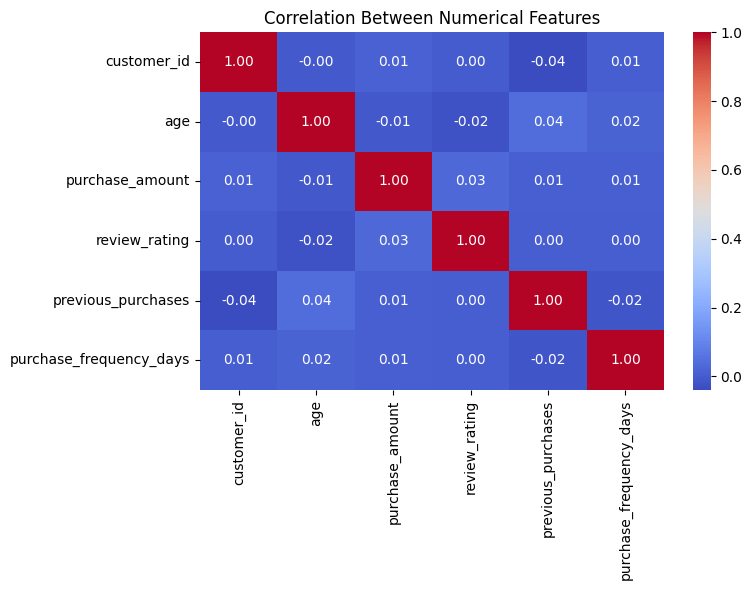

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")

plt.tight_layout()
plt.show()

### Business Insights

- Examine relationships among numerical variables.
- Identify strongly correlated features for deeper analysis.
- Most variables show weak correlations, indicating independent customer attributes.

# Key Business Insights

- Clothing is the highest revenue-generating product category.
- Outerwear contributes the lowest revenue.
- Young Adult and Middle-aged customers generate significant revenue.
- Male customers contribute higher revenue than female customers.
- Subscription behavior influences overall sales performance.
- Free Shipping is among the most preferred delivery options.
- Customer review ratings are generally positive and stable.
- The dataset shows no strong correlation among numerical variables.

# Export Dataset to MySQL Database

### Objective
Export the cleaned customer shopping dataset to a MySQL database for SQL querying and business analysis.

In [27]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "root"
password = quote_plus("@201517#aa")
host = "localhost"
port = "3306"
database = "customer_behavior"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

table_name = "customer"

df.to_sql(
    table_name,
    engine,
    if_exists="replace",
    index=False
)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'customer' in database 'customer_behavior'.


In [ ]:
pip install pymysql sqlalchemy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
